# Import libraries

In [32]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# Load Ground Truth

In [33]:
def load_gt(gt_fname):
    with open(gt_fname) as f:
        gt = json.load(f)

    rows_gt = []
    for video_id, info in gt["database"].items():
        duration = info["duration"]
        subset = info["subset"]
        for s in info["annotations"]:
            rows_gt.append(
                {
                    "video_id": video_id,
                    "duration": duration,
                    "subset": subset,
                    "start": s["segment"][0],
                    "end": s["segment"][1],
                    "label": s["label"],
                }
            )

    return pd.DataFrame(rows_gt)

### Load full ground truth

In [34]:
gt_df = load_gt("../data/charades/annotations/charades.json")

# Load ground truth function

### Load sample ground truth (10 least frequent classes)

In [35]:
least_sample_gt_df = load_gt("../data/charades/annotations/least_sample_charades.json")
print(least_sample_gt_df.shape)
least_sample_gt_df.head()

(449, 6)


,video_id,duration,subset,start,end,label
0,028CE,20.00,training,2.0,11.0,Fixing a vacuum
1,03EW0,31.12,training,0.0,2.6,Throwing a box somewhere
2,06EDS,35.46,training,23.6,36.0,Making a sandwich
3,08AQS,32.33,training,29.1,33.0,Throwing a box somewhere
4,08LOY,28.04,testing,5.7,21.9,Fixing a light


### Load sample ground truth (10 most frequent classes)

In [36]:
most_sample_gt_df = load_gt("../data/charades/annotations/most_sample_charades.json")
print(most_sample_gt_df.shape)
most_sample_gt_df.head()

(500, 6)


,video_id,duration,subset,start,end,label
0,02CYP,31.79,training,5.5,10.8,Holding a cup/glass/bottle of something
1,0D5I8,30.58,training,0.0,18.2,Holding a phone/camera
2,0I1S5,30.38,training,16.6,22.5,Someone is smiling
3,0TDOP,30.42,testing,12.8,31.0,Someone is eating something
4,0UFI4,46.96,training,12.8,21.3,Someone is going from standing to sitting


### Load predictions

In [64]:
with open("../exps/charades/actionformer_i3d_rgb/result_detection.json", "r") as f:
  predictions = json.load(f)

rows_predictions = []
for video_id, segments in predictions['results'].items():
  for s in segments:
    rows_predictions.append({
      'video_id': video_id,
      'start': s['segment'][0],
      'end': s['segment'][1],
      'label': s['label'],
      'score': s['score']
    })
  
predictions_df = pd.DataFrame(rows_predictions)
predictions_df.sample(50)

,video_id,start,end,label,score
63584,DLOS7,29.17,30.93,Drinking from a cup/glass/bottle,0.0100
151308,W0J8C,14.18,16.35,Someone is smiling,0.0033
108456,NBKCK,4.52,7.88,Walking through a doorway,0.1141
2637,0TDOP,11.61,13.66,Walking through a doorway,0.0054
78649,H46LQ,21.50,23.36,Someone is smiling,0.0026
67454,EG0VZ,15.63,17.64,Sitting in a chair,0.0032
102132,LUQWY,3.37,5.43,Holding a cup/glass/bottle of something,0.0023
24422,4KYZH,11.45,13.29,Holding a cup/glass/bottle of something,0.0030
34008,7XCAP,23.49,25.59,Someone is going from standing to sitting,0.0011
96338,KTXSD,-0.00,1.37,Holding a cup/glass/bottle of something,0.0038


In [38]:
predictions_df.shape

(88588, 5)

# Plot Predictions against Ground Truth

In [ ]:
def plot_predictions_vs_gt(predictions_df, gt_df, video_id, confidence_threshold=0.04):
    # predictions for the video
    predicted_video = predictions_df[
        (predictions_df["video_id"] == video_id)
        & (predictions_df["score"] > confidence_threshold)
    ]
    # ground truth for the video
    video = gt_df[gt_df["video_id"] == video_id]

    # Plot predictions against ground truth
    fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    for _, row in predicted_video.iterrows():
        ax[0].plot([row["start"], row["end"]], [row["label"]] * 2)
    ax[0].set_title("Prediction")

    for _, row in video.iterrows():
        ax[1].plot([row["start"], row["end"]], [row["label"]] * 2)
    ax[1].set_title("Ground Truth")

    plt.xlabel("Second")
    plt.tight_layout()
    plt.show()

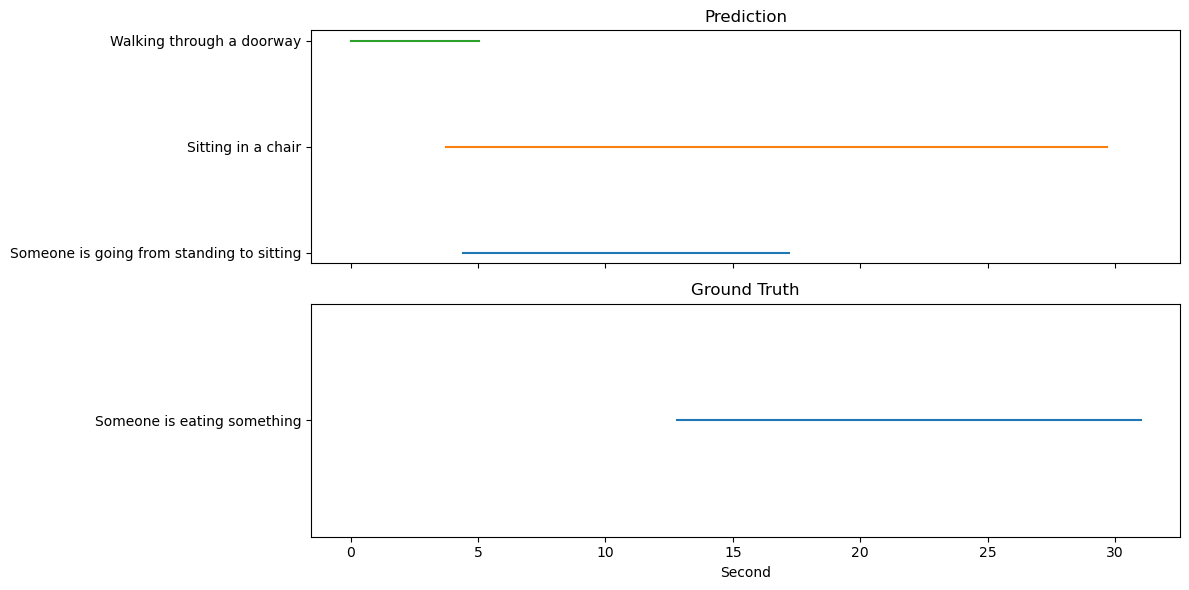

In [70]:
plot_predictions_vs_gt(predictions_df, most_sample_gt_df, "0TDOP", confidence_threshold=0.3)

# Overlapping Analysis

In [40]:
def calculate_overlap_density(df, video_id):
    # Filter rows for the given video
    video_df = df[df["video_id"] == video_id].copy()

    if len(video_df) < 2:
        return 0.0  # No overlap possible with fewer than 2 segments

    # Get total video duration (assume all rows have the same duration)
    total_duration = video_df["duration"].iloc[0]

    # Build a list of (start, end) tuples
    intervals = list(zip(video_df["start"], video_df["end"]))

    # Create a timeline of second-level granularity
    timeline = [0.0] * int(total_duration * 10)  # use deci-seconds for precision

    # Mark timeline per action
    for start, end in intervals:
        for t in range(int(start * 10), int(end * 10)):
            if 0 <= t < len(timeline):
                timeline[t] += 1

    # Count overlapping time points (where >1 action occurs)
    overlap_count = sum(1 for t in timeline if t > 1)

    # Convert back to seconds
    overlap_duration = overlap_count / 10.0

    # Compute and return overlap density
    return overlap_duration / total_duration

In [63]:
gt_df['overlap_density'] = gt_df['video_id'].apply(lambda x: calculate_overlap_density(gt_df, x))
gt_df['overlap_density'].describe()

count    66500.000000
mean         0.808586
std          0.230699
min          0.000000
25%          0.680897
50%          0.904402
75%          0.997545
max          1.000000
Name: overlap_density, dtype: float64